In [22]:
import json
import pandas as pd
import numpy as np

Supervisor

In [23]:
with open('metricas\supervisor.json', 'r', encoding='utf-8') as archivo:
    datos = json.load(archivo)

In [24]:
df_modelo = {}
modelos = list(datos['supervisor'].keys())
modelos_del=['hengwen/watt-tool-8B:latest',
 'hengwen/watt-tool-8B', 'kitsonk/watt-tool-8B',
 'fireshihtzu/watt-tool-8B-formatted', 'hf.co/eaddario/Watt-Tool-8B-GGUF:F16', 'hf.co/mradermacher/BitAgent-8B-GGUF:IQ4_XS', 'deepseek-r1:14b']
modelo_list=list(set(modelos)-set(modelos_del))
modelo_list

['hf.co/Eddie-3dd13/ToolACE-2-Llama-3.1-8B-Q8_0-GGUF:Q8_0',
 'hf.co/Salesforce/Llama-xLAM-2-8b-fc-r-gguf:F16',
 'qwen3:14b',
 'qwen2.5:14b',
 'hf.co/jedisct1/MiMo-7B-RL-GGUF:Q4_K_M',
 'MFDoom/deepseek-r1-tool-calling:14b']

In [30]:
df_modelo = {}
modelos = list(datos['supervisor'].keys())
modelos_del=['hengwen/watt-tool-8B:latest',
 'hengwen/watt-tool-8B', 'kitsonk/watt-tool-8B',
 'fireshihtzu/watt-tool-8B-formatted', 'hf.co/eaddario/Watt-Tool-8B-GGUF:F16', 'hf.co/mradermacher/BitAgent-8B-GGUF:IQ4_XS', 'deepseek-r1:14b']
modelo_list=list(set(modelos)-set(modelos_del))

for modelo in modelo_list:
    print(modelo)
    metricas = datos['supervisor'][modelo]
    filas = []
    for key, value in metricas.items():
        fila = {
            'time': value['metricas']['time'],
            #'goal': value['metricas']['goal'],
            'tool': value['metricas']['tool'],
            'description': value['description']
        }
        filas.append(fila)

    df = pd.DataFrame(filas, index=metricas.keys())
    df_modelo[modelo] = df

hf.co/Eddie-3dd13/ToolACE-2-Llama-3.1-8B-Q8_0-GGUF:Q8_0
hf.co/Salesforce/Llama-xLAM-2-8b-fc-r-gguf:F16
qwen3:14b
qwen2.5:14b
hf.co/jedisct1/MiMo-7B-RL-GGUF:Q4_K_M
MFDoom/deepseek-r1-tool-calling:14b


In [26]:
df = pd.concat(df_modelo, names=["modelos", "idx"])
df

time  tool  \
modelos                                            idx                    
hf.co/Eddie-3dd13/ToolACE-2-Llama-3.1-8B-Q8_0-G... 0    27.292491   0.0   
                                                   1    18.113765   0.0   
                                                   2    19.583920   0.0   
                                                   3    17.740817   0.0   
                                                   4    25.421136   1.0   
...                                                           ...   ...   
MFDoom/deepseek-r1-tool-calling:14b                7    27.483280   1.0   
                                                   8    29.688841   1.0   
                                                   9    29.618329   1.0   
                                                   10   23.668658   1.0   
                                                   11   43.347939   1.0   

                                                                                              description  
modelos                                            idx                                                     
hf.co/Eddie-3dd13/ToolACE-2-Llama-3.1-8B-Q8_0-G... 0       TC 1 (Recuperador): Delegate Humectacion Query  
                                                   1             TC 2 (Recuperador): Delegate Litio Query  
                                                   2          TC 3 (Graficador): Delegate Line Plot Query  
                                                   3          TC 4 (Graficador): Delegate Histogram Query  
                                                   4    TC 5 (RAG): Delegate Producción Ministro Hales...  
...                                                                                                   ...  
MFDoom/deepseek-r1-tool-calling:14b                7        TC 8 (RAG): Delegate Mineral Importante Query  
                                                   8            TC 9 (RAG): Delegate PIB Cobre 2023 Query  
                                                   9       TC 10 (RAG): Delegate Reserva Plata 2016 Query  
                                                   10   TC 11 (RAG): Delegate Componentes Retroexcavad...  
                                                   11       TC 12 (RAG): Delegate Brazo Telescópico Query  

[72 rows x 3 columns]

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

#sns.countplot(data=df, x='goal', hue='modelos')
#plt.title('Cantidad de aciertos por modelo (goal)')
#plt.show()


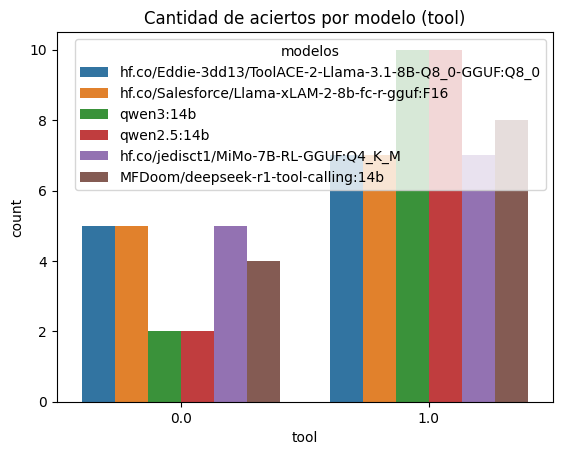

In [28]:
sns.countplot(data=df, x='tool', hue='modelos')
plt.title('Cantidad de aciertos por modelo (tool)')
plt.show()


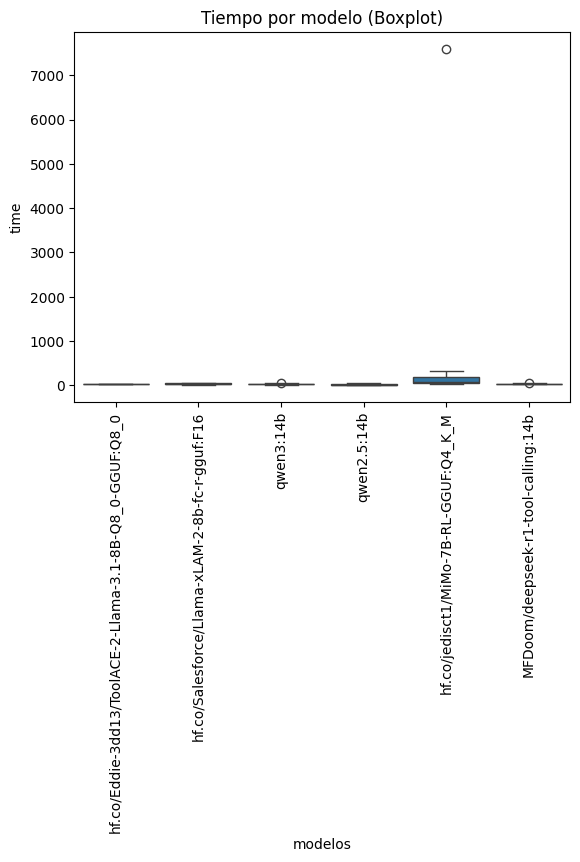

In [29]:
sns.boxplot(data=df, x='modelos', y='time')
plt.title('Tiempo por modelo (Boxplot)')
plt.xticks(rotation=90)
plt.show()

In [31]:
df_modelo = {}
modelos = list(datos['supervisor'].keys())
modelos_del=['hengwen/watt-tool-8B:latest',
 'hengwen/watt-tool-8B', 'kitsonk/watt-tool-8B',
 'fireshihtzu/watt-tool-8B-formatted', 'hf.co/eaddario/Watt-Tool-8B-GGUF:F16', 'hf.co/mradermacher/BitAgent-8B-GGUF:IQ4_XS', 'deepseek-r1:14b', 'hf.co/jedisct1/MiMo-7B-RL-GGUF:Q4_K_M']
modelo_list=list(set(modelos)-set(modelos_del))
modelo_list

for modelo in modelo_list:
    print(modelo)
    metricas = datos['supervisor'][modelo]
    filas = []
    for key, value in metricas.items():
        fila = {
            'time': value['metricas']['time'],
            #'goal': value['metricas']['goal'],
            'tool': value['metricas']['tool'],
            'description': value['description']
        }
        filas.append(fila)

    df = pd.DataFrame(filas, index=metricas.keys())
    df_modelo[modelo] = df

hf.co/Eddie-3dd13/ToolACE-2-Llama-3.1-8B-Q8_0-GGUF:Q8_0
hf.co/Salesforce/Llama-xLAM-2-8b-fc-r-gguf:F16
qwen3:14b
qwen2.5:14b
MFDoom/deepseek-r1-tool-calling:14b


In [32]:
df = pd.concat(df_modelo, names=["modelos", "idx"])
df

time  tool  \
modelos                                            idx                    
hf.co/Eddie-3dd13/ToolACE-2-Llama-3.1-8B-Q8_0-G... 0    27.292491   0.0   
                                                   1    18.113765   0.0   
                                                   2    19.583920   0.0   
                                                   3    17.740817   0.0   
                                                   4    25.421136   1.0   
                                                   5    19.428566   0.0   
                                                   6    32.413935   1.0   
                                                   7    20.915977   1.0   
                                                   8    19.658297   1.0   
                                                   9    24.682880   1.0   
                                                   10   18.670197   1.0   
                                                   11   28.366726   1.0   
hf.co/Salesforce/Llama-xLAM-2-8b-fc-r-gguf:F16     0    57.267135   1.0   
                                                   1    31.810169   1.0   
                                                   2    31.576019   0.0   
                                                   3    23.355344   0.0   
                                                   4    40.110463   1.0   
                                                   5    53.294514   1.0   
                                                   6    17.093479   0.0   
                                                   7    14.797240   0.0   
                                                   8    16.526021   0.0   
                                                   9    33.632978   1.0   
                                                   10   36.175288   1.0   
                                                   11   43.418691   1.0   
qwen3:14b                                          0    21.635745   1.0   
                                                   1    18.673705   1.0   
                                                   2    20.375459   0.0   
                                                   3    16.881243   0.0   
                                                   4    22.947342   1.0   
                                                   5    21.138335   1.0   
                                                   6    43.534916   1.0   
                                                   7    30.353477   1.0   
                                                   8    23.315316   1.0   
                                                   9    28.647757   1.0   
                                                   10   49.537118   1.0   
                                                   11   33.696883   1.0   
qwen2.5:14b                                        0    15.908175   1.0   
                                                   1    11.735583   1.0   
                                                   2    13.858151   0.0   
                                                   3    11.008482   0.0   
                                                   4    14.170320   1.0   
                                                   5    34.451620   1.0   
                                                   6    34.219418   1.0   
                                                   7    23.442450   1.0   
                                                   8    16.015957   1.0   
                                                   9    23.626099   1.0   
                                                   10   43.886329   1.0   
                                                   11   18.603400   1.0   
MFDoom/deepseek-r1-tool-calling:14b                0    18.126699   0.0   
                                                   1    19.065402   0.0   
                                                   2    20.217460   0.0   
                                                   3    17.985748   0.0   
           

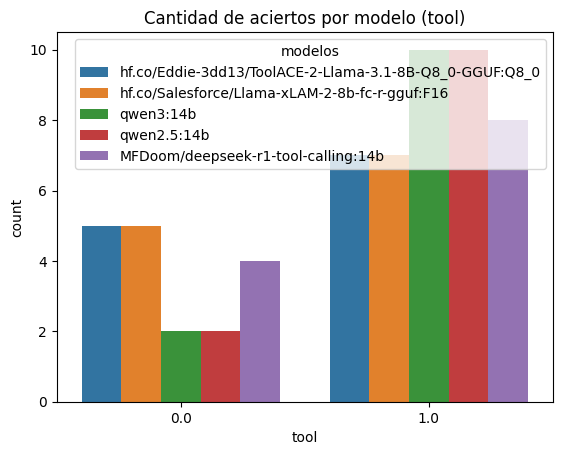

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='tool', hue='modelos')
plt.title('Cantidad de aciertos por modelo (tool)')
plt.show()

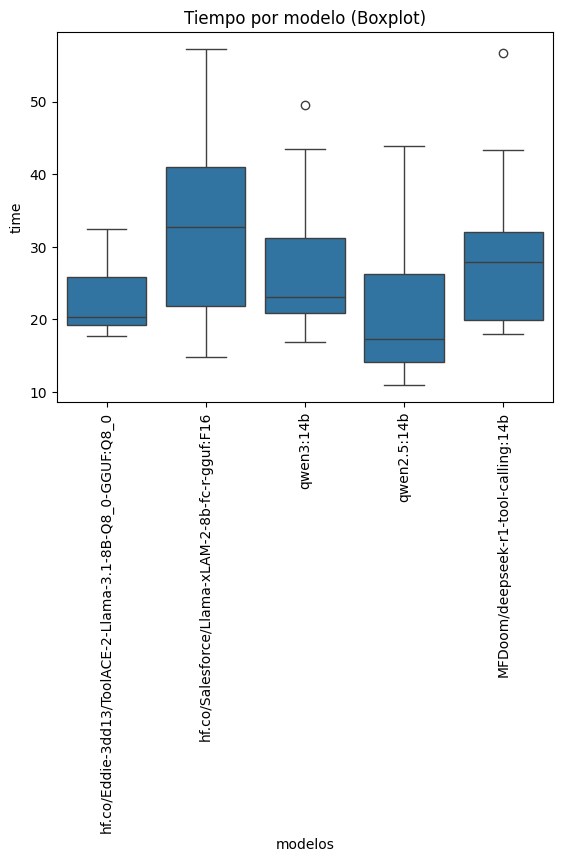

In [34]:
sns.boxplot(data=df, x='modelos', y='time')
plt.title('Tiempo por modelo (Boxplot)')
plt.xticks(rotation=90)
plt.show()